#Data Loading

In [15]:
import pandas as pd

# if dataset is in same folder as your notebook / pycharm
df = pd.read_csv("Churn_Modelling.csv")





In [17]:
# basic checks
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
import pandas as pd


(10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4

In [19]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [21]:
df.describe()
     

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


#Data Cleaning

In [23]:

# remove irrelevant columns
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# check missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# fill numerical missing values 
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# fill categorical missing values
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:\n", df.isnull().sum())
print(df.head())
print(df.info())


Missing values before cleaning:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Missing values after cleaning:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1 

#Exploratory Data Analysis (EDA)

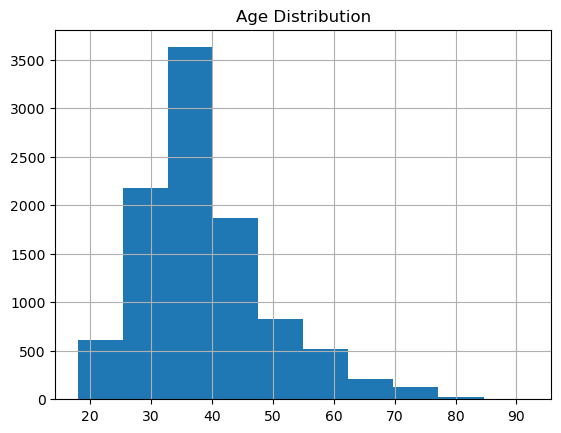

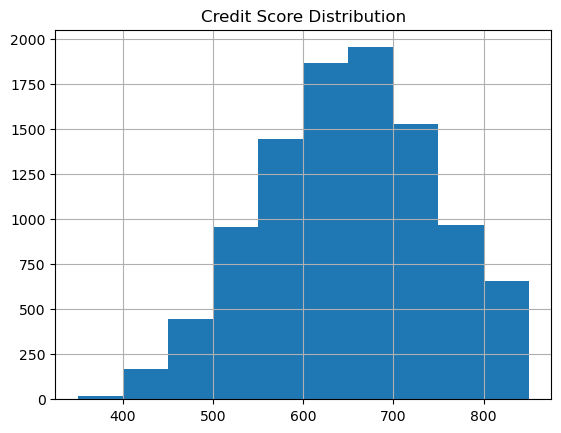

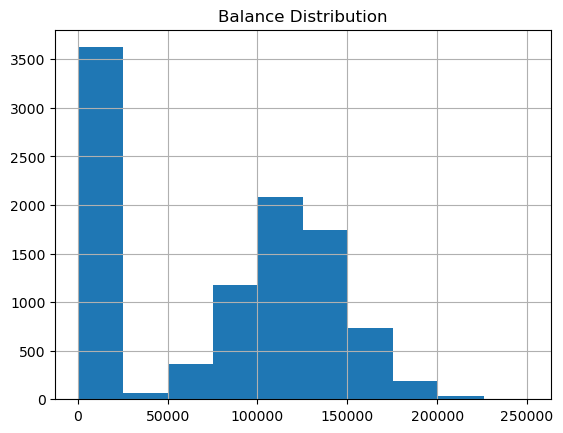

In [25]:
# univariant  analysis
import matplotlib.pyplot as plt

df['Age'].hist()
plt.title("Age Distribution")
plt.show()

df['CreditScore'].hist()
plt.title("Credit Score Distribution")
plt.show()

df['Balance'].hist()
plt.title("Balance Distribution")
plt.show()


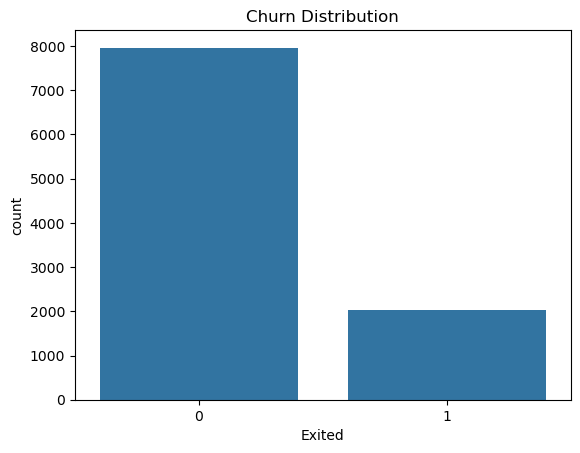

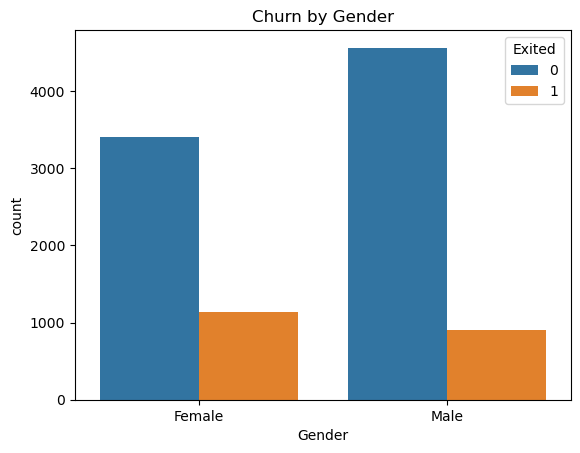

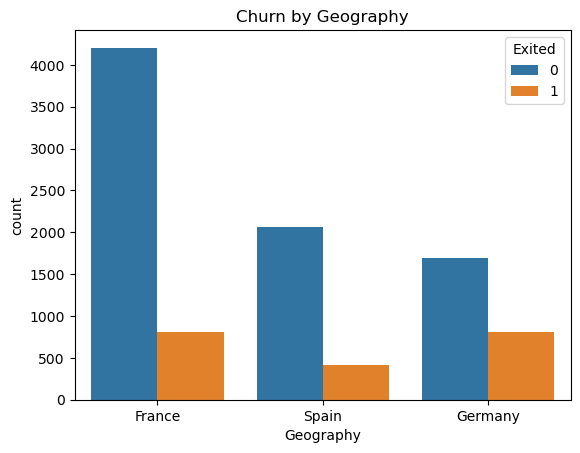

In [27]:
#Churn vs Features
import seaborn as sns

# churn count
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

# churn by gender
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Churn by Gender")
plt.show()

# churn by geography
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Churn by Geography")
plt.show()


In [31]:
# convert categorical to numeric temporarily for EDA
df_eda = df.copy()

df_eda['Gender'] = df_eda['Gender'].map({'Male':1, 'Female':0})

# one-hot encode geography
df_eda = pd.get_dummies(df_eda, columns=['Geography'], drop_first=True)


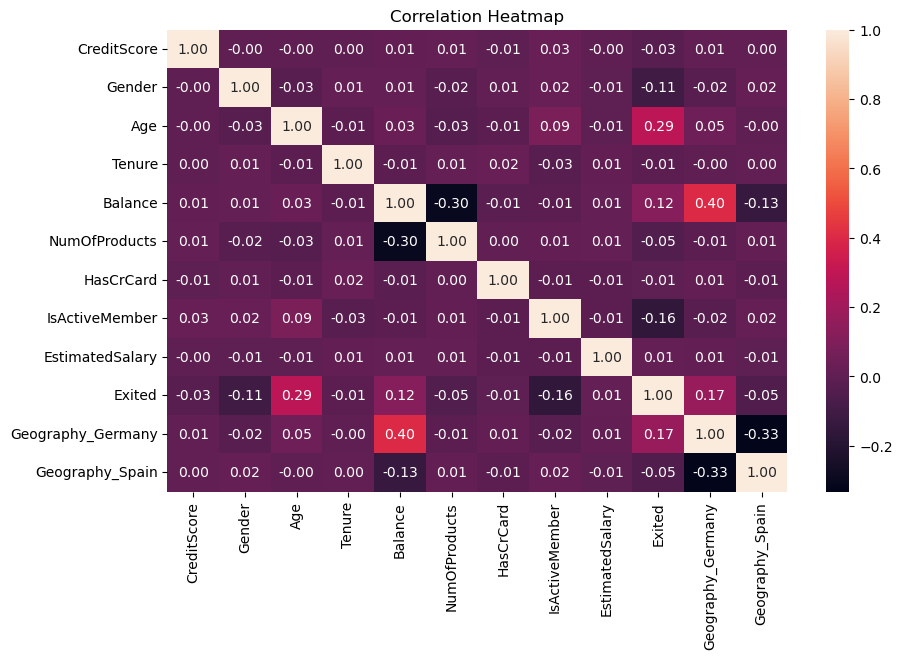

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df_eda.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


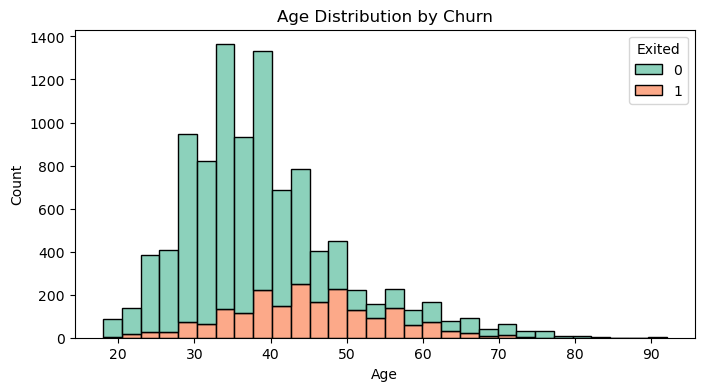

In [87]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Age', hue='Exited', multiple='stack', bins=30, palette='Set2')
plt.title("Age Distribution by Churn")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()



C:\Users\soft\AppData\Local\Temp\ipykernel_5644\638814333.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df, palette='Set3')


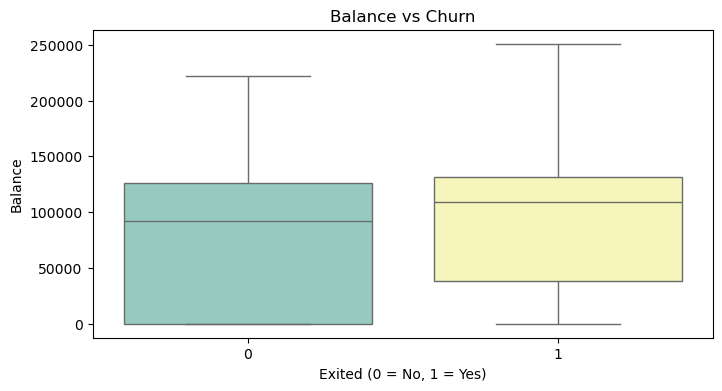

In [89]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Exited', y='Balance', data=df, palette='Set3')
plt.title("Balance vs Churn")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Balance")
plt.show()


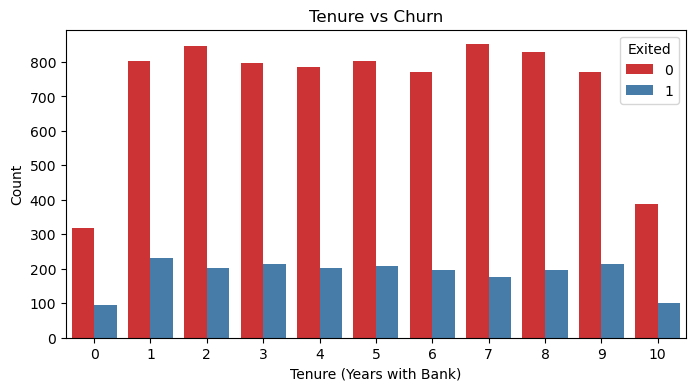

In [91]:
plt.figure(figsize=(8,4))
sns.countplot(x='Tenure', hue='Exited', data=df, palette='Set1')
plt.title("Tenure vs Churn")
plt.xlabel("Tenure (Years with Bank)")
plt.ylabel("Count")
plt.show()


#Feature Engineering and Scaling

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
#  Encode Categorical Variables
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)



In [39]:
#  Define X and y
X = df.drop('Exited', axis=1)
y = df['Exited']

In [41]:
#  Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [43]:
#  Feature Scaling (only numeric features)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [47]:
#handle  class imbalance
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)


#Model Development and Training

In [61]:
# Logestic Regression 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:,1]


In [63]:
#Random forest 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]


In [65]:
# XGBoost 
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:,1]


C:\Users\soft\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:07:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [71]:
#Model Evaluation and Insights

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

models = {
    "Logistic Regression": (y_pred_lr, y_proba_lr),
    "Random Forest": (y_pred_rf, y_proba_rf),
    "XGBoost": (y_pred_xgb, y_proba_xgb)
}

for name, (pred, proba) in models.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, proba)

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall:", round(rec,4))
    print("F1:", round(f1,4))
    print("ROC AUC:", round(roc,4))
   



=== Logistic Regression ===
Accuracy: 0.7155
Precision: 0.389
Recall: 0.6978
F1: 0.4996
ROC AUC: 0.7769

=== Random Forest ===
Accuracy: 0.839
Precision: 0.6055
Recall: 0.5995
F1: 0.6025
ROC AUC: 0.8496

=== XGBoost ===
Accuracy: 0.8515
Precision: 0.658
Recall: 0.5627
F1: 0.6066
ROC AUC: 0.838


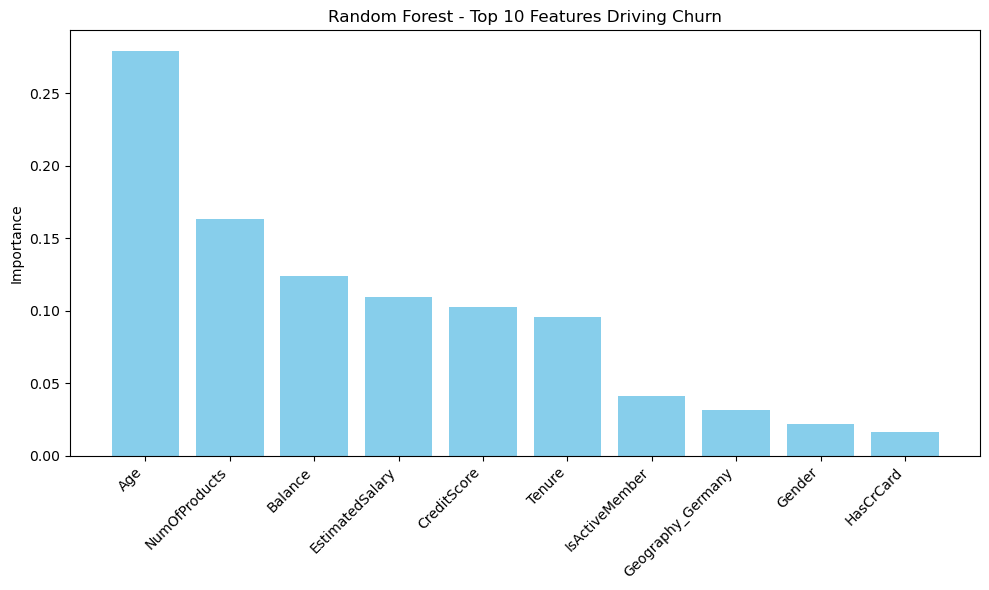

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

# feature names
feature_names = X.columns

# Random Forest feature importance
rf_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Top 10
top10_rf = rf_importances.head(10)

# Vertical Bar Chart
plt.figure(figsize=(10,6))
plt.bar(top10_rf['Feature'], top10_rf['Importance'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Random Forest - Top 10 Features Driving Churn")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()




In [95]:
import pandas as pd

# Use your original CustomerId
df_customers = pd.read_csv("Churn_Modelling.csv")[['CustomerId']]

# Random Forest predictions
df_customers['RF_Probability'] = rf.predict_proba(scaler.transform(X))[:,1]
df_customers['RF_Predicted'] = (df_customers['RF_Probability'] >= 0.5).astype(int)

# Logistic Regression predictions
df_customers['LR_Probability'] = lr.predict_proba(scaler.transform(X))[:,1]
df_customers['LR_Predicted'] = (df_customers['LR_Probability'] >= 0.5).astype(int)

# XGBoost predictions
df_customers['XGB_Probability'] = xgb_clf.predict_proba(scaler.transform(X))[:,1]
df_customers['XGB_Predicted'] = (df_customers['XGB_Probability'] >= 0.5).astype(int)

# Save to CSV
df_customers.to_csv("Churn_Model_Predictions.csv", index=False)

print("All model predictions saved to 'Churn_Model_Predictions.csv'")


C:\Users\soft\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\soft\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\soft\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


All model predictions saved to 'Churn_Model_Predictions.csv'
